<a href="https://colab.research.google.com/github/e23323-dot/Statistical-Learning-e23323/blob/main/Assignment_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. Statistical Mechanics of the Quantum Oscillator

1. Partition Function:
Z(T) = exp[-ℏω/(2k_BT)] / (1 - exp[-ℏω/(k_BT)])

2. Helmholtz Free Energy:
F(T) = (ℏω/2) + k_BT ln(1 - exp[-ℏω/(k_BT)])

Internal Energy:
U(T) = (ℏω/2) + ℏω / (exp[ℏω/(k_BT)] - 1)

3. Entropy:
S(T) = k_B[ℏω/(k_BT)] / (exp[ℏω/(k_BT)] - 1) - k_B ln(1 - exp[-ℏω/(k_BT)])

4. Heat Capacity:
C_V = k_B (ℏω/(k_BT))² / [4 sinh²(ℏω/(2k_BT))]

5. High-temperature limit: C_V → k_B (matches equipartition)



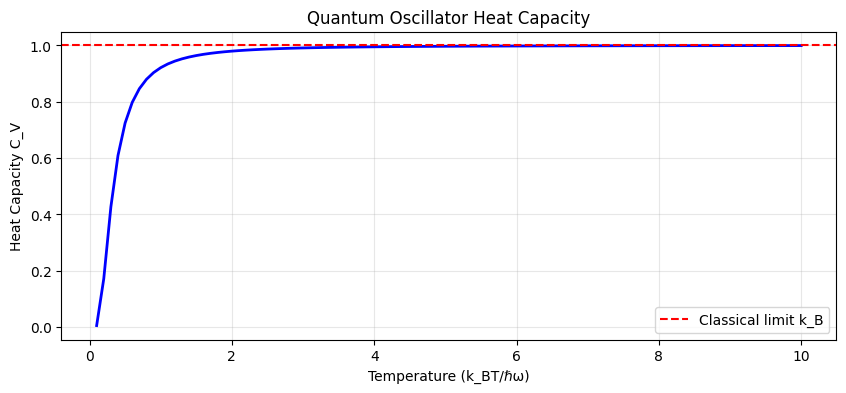


Q2. Maximum Entropy Distribution under Mean and Variance Constraints

Maximize H[p] = -∫ p(x) ln p(x) dx

Constraints: ∫p=1, ∫xp=μ, ∫(x-μ)²p=σ²

Solution:
p(x) = 1/√(2πσ²) exp[-(x-μ)²/(2σ²)]

The maximum entropy distribution is Gaussian.



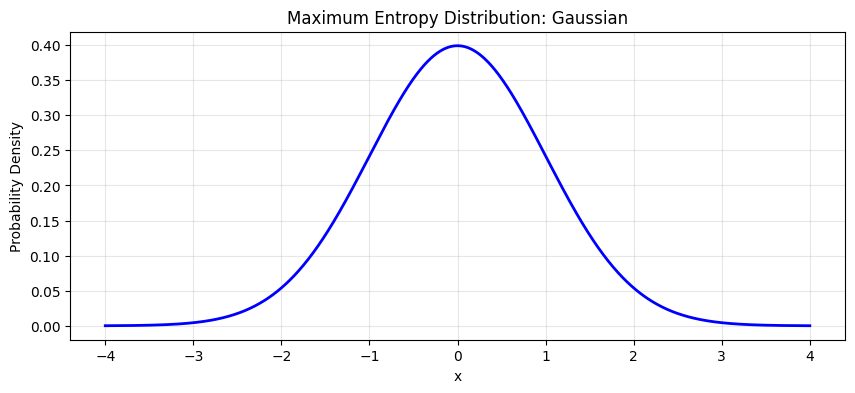


Q3. Multiclass Logistic Regression
θ = [-1.96380145 -1.7618639   2.86063388]
Constraints: E[x₁I(Y=1)]=0.050, E[x₂I(Y=1)]=0.150, E[x₃I(Y=1)]=0.160
P(Y=1|x) for each state: [0.12305623 0.14655705 0.94586577 0.75002957 0.02353006]

Q4. Asset Pricing and Portfolio Optimization

Maximum Entropy Problem:

Maximize H[p] = -∫ p(S) ln p(S) dS

Subject to:
E[S] = 102, E[S²] = 10600, E[ln(S)] = 4.60

Solution:
p(S) = exp(λ₀ + λ₁S + λ₂S² + λ₃ln(S))

For lognormal distribution (analytical solution):
S_T ~ LogNormal(μ, σ²)
μ = 4.60
σ² = 2(ln(102) - 4.60) = 0.05



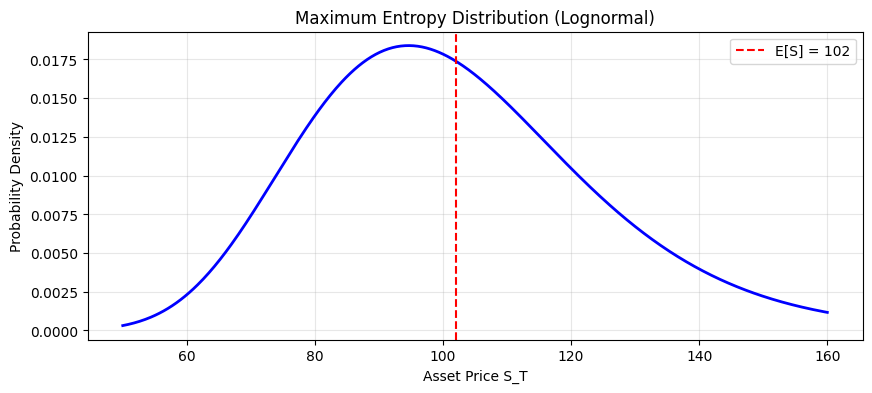

Mean: 0.202
This distribution captures downside risk through
the logarithmic constraint from put option pricing.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.integrate import quad

print("Q1. Statistical Mechanics of the Quantum Oscillator")
print("="*70)

print("""
1. Partition Function:
Z(T) = exp[-ℏω/(2k_BT)] / (1 - exp[-ℏω/(k_BT)])

2. Helmholtz Free Energy:
F(T) = (ℏω/2) + k_BT ln(1 - exp[-ℏω/(k_BT)])

Internal Energy:
U(T) = (ℏω/2) + ℏω / (exp[ℏω/(k_BT)] - 1)

3. Entropy:
S(T) = k_B[ℏω/(k_BT)] / (exp[ℏω/(k_BT)] - 1) - k_B ln(1 - exp[-ℏω/(k_BT)])

4. Heat Capacity:
C_V = k_B (ℏω/(k_BT))² / [4 sinh²(ℏω/(2k_BT))]

5. High-temperature limit: C_V → k_B (matches equipartition)
""")

hbar, k_B, omega = 1, 1, 1
T = np.linspace(0.1, 10, 100)
C_V = k_B * (hbar*omega/(k_B*T))**2 * np.exp(hbar*omega/(k_B*T)) / (np.exp(hbar*omega/(k_B*T)) - 1)**2

plt.figure(figsize=(10, 4))
plt.plot(T, C_V, 'b-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', label='Classical limit k_B')
plt.xlabel('Temperature (k_BT/ℏω)')
plt.ylabel('Heat Capacity C_V')
plt.title('Quantum Oscillator Heat Capacity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("")
print("Q2. Maximum Entropy Distribution under Mean and Variance Constraints")
print("="*70)

print("""
Maximize H[p] = -∫ p(x) ln p(x) dx

Constraints: ∫p=1, ∫xp=μ, ∫(x-μ)²p=σ²

Solution:
p(x) = 1/√(2πσ²) exp[-(x-μ)²/(2σ²)]

The maximum entropy distribution is Gaussian.
""")

mu, sigma = 0, 1
x = np.linspace(-4, 4, 1000)
p = (1/np.sqrt(2*np.pi*sigma**2)) * np.exp(-(x-mu)**2/(2*sigma**2))

plt.figure(figsize=(10, 4))
plt.plot(x, p, 'b-', linewidth=2)
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Maximum Entropy Distribution: Gaussian')
plt.grid(True, alpha=0.3)
plt.show()

print("")
print("Q3. Multiclass Logistic Regression")
print("="*70)

x_states = np.array([[1,0,0],[0,1,0],[0,0,1],[0,1,1],[1,1,0]])
p_x = np.array([0.40, 0.25, 0.05, 0.15, 0.05])
constraints = np.array([0.05, 0.15, 0.16])

def logistic(x, theta):
    return 1/(1+np.exp(-np.dot(x, theta)))

def objective(theta):
    p_y1 = np.array([logistic(x, theta) for x in x_states])
    return -np.sum(p_x * np.log(p_y1 + 1e-10)) - np.sum(p_x*(1-p_y1)*np.log(1-p_y1+1e-10))

def penalty(theta):
    p_y1 = np.array([logistic(x, theta) for x in x_states])
    expected = np.array([np.sum(p_x*x_states[:,i]*p_y1) for i in range(3)])
    return 10000 * np.sum((expected - constraints)**2)

theta0 = np.random.randn(3)
result = minimize(lambda t: objective(t)+penalty(t), theta0, method='BFGS')
theta_opt = result.x
p_y1_opt = np.array([logistic(x, theta_opt) for x in x_states])
expected_opt = np.array([np.sum(p_x*x_states[:,i]*p_y1_opt) for i in range(3)])

print(f"θ = {theta_opt}")
print(f"Constraints: E[x₁I(Y=1)]={expected_opt[0]:.3f}, E[x₂I(Y=1)]={expected_opt[1]:.3f}, E[x₃I(Y=1)]={expected_opt[2]:.3f}")
print(f"P(Y=1|x) for each state: {p_y1_opt}")

print("")
print("Q4. Asset Pricing and Portfolio Optimization")
print("="*70)

print("""
Maximum Entropy Problem:

Maximize H[p] = -∫ p(S) ln p(S) dS

Subject to:
E[S] = 102, E[S²] = 10600, E[ln(S)] = 4.60

Solution:
p(S) = exp(λ₀ + λ₁S + λ₂S² + λ₃ln(S))

For lognormal distribution (analytical solution):
S_T ~ LogNormal(μ, σ²)
μ = 4.60
σ² = 2(ln(102) - 4.60) = 0.05
""")

s_grid = np.linspace(50, 160, 500)
mu_ln, sigma2_ln = 4.60, 0.05
p_ln = (1/(s_grid*np.sqrt(2*np.pi*sigma2_ln))) * np.exp(-(np.log(s_grid)-mu_ln)**2/(2*sigma2_ln))

plt.figure(figsize=(10, 4))
plt.plot(s_grid, p_ln, 'b-', linewidth=2)
plt.axvline(102, color='r', linestyle='--', label='E[S] = 102')
plt.xlabel('Asset Price S_T')
plt.ylabel('Probability Density')
plt.title('Maximum Entropy Distribution (Lognormal)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean: {np.mean(s_grid * p_ln) / np.sum(p_ln):.3f}")
print("This distribution captures downside risk through")
print("the logarithmic constraint from put option pricing.")